In [1]:
"""
FINUFFT
Here I provide a first try at getting FINUFFT to work. The first step is to install finufft on Tycho,
as far as I recall I simply did

pip install finufft
"""

import finufft
import paicos as pa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# Load a snapshot and select spherical region (?)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
R200c = snap.Cat.Group['Group_R_Crit200'][0]
r_max = 1.0 * R200c
# index = pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0., r_max)

widths = np.array([2e3, 2e3, 2e3], dtype=float)
index = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], center, widths, snap.box)
snap = snap.select(index, parttype=0)



In [2]:
snap['0_Coordinates'].shape

(12515, 3)

In [3]:
snap['0_Coordinates'][:, 0]

<PaicosQuantity [398974.38664031, 398976.06220306, 398964.31625223, ...,
                 398188.35831544, 399801.08658404, 399808.65546007] arepo_length small_a / small_h>

In [4]:
M = snap['0_Coordinates'].shape[0]
# A simple example,
# https://finufft.readthedocs.io/en/latest/python.html#quick-start-examples
# https://finufft.readthedocs.io/en/latest/python.html#finufft.Plan


# k1 = 1.0 * 2 * np.pi
# k2 = 0.0 * 2 * np.pi
# k3 = 0.0 * 2 * np.pi

# the nonuniform points (rescaled to -1 to 1), should be -pi to pi?
# x = (snap['0_Coordinates'][:, 0] - center[0]).value / R200c.value
# y = (snap['0_Coordinates'][:, 1] - center[1]).value / R200c.value
# z = (snap['0_Coordinates'][:, 2] - center[2]).value / R200c.value

# I think it should be 0, 2pi

x = 2 * np.pi * (snap['0_Coordinates'][:, 0].value - ( center[0].value - widths[0]/2. )) / widths[0]
y = 2 * np.pi * (snap['0_Coordinates'][:, 1].value - ( center[1].value - widths[1]/2. )) / widths[1]
z = 2 * np.pi * (snap['0_Coordinates'][:, 2].value - ( center[2].value - widths[2]/2. )) / widths[2]

# # their complex strengths
# c = snap['0_Density'].value + 0.0j
c = (np.random.standard_normal(size=M)
     + 1J * 0.0)


In [5]:
grid_size = 10
# c = np.exp(1j*k1*x + 1j*k2*y + 1j*k3*z).real + 0.0j

# # desired number of Fourier modes

kx = np.arange(0, grid_size)*1.0
ky = np.arange(0, grid_size)*1.0
kz = np.arange(0, grid_size)*1.0

# kx = np.logspace(-2, 2, grid_size)*2*np.pi
# ky = np.logspace(-2, 2, grid_size)*2*np.pi
# kz = np.logspace(-2, 2, grid_size)*2*np.pi

kxx, kyy, kzz = np.meshgrid(kx, ky, kz)

kx = kxx.flatten()
ky = kyy.flatten()
kz = kzz.flatten()


# calculate the NUFFT
f = finufft.nufft3d3(x, y, z, c, kx, ky, kz)
k = np.sqrt(kx**2 + ky**2 + kz**2)
# k_index = np.argsort(k)
# k1d = k[k_index]
# f1d = f[k_index]

# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kmax = 
kmin = k.min()
kmax = k.max()

k1d = np.arange(kmin, kmax+1.0, 1.0)
power1d = np.zeros(k1d.shape)

for i in range(k1d.shape[0]):
    indices = np.argwhere(k==k1d[i])
    if (indices.size != 0):
        power1d[i] = np.sum(np.abs(f[indices]))



In [6]:
kmax

15.588457268119896

In [7]:
k1d

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

In [8]:
power1d

array([  28.20907053,  338.69559152,  284.48570625,  667.6042893 ,
        334.70036617, 1050.45880784,  400.97744428,  945.7765661 ,
        197.30376754, 1519.39688034,  393.09562752, 1067.27035749,
        321.17332355,    0.        ,    0.        ,    0.        ,
          0.        ])

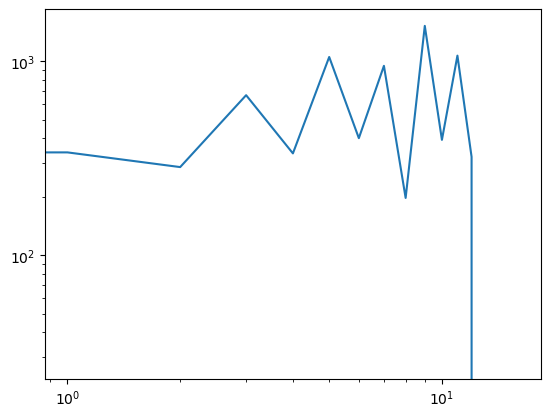

In [9]:

plt.figure(1)
plt.clf()
plt.loglog(k1d, power1d)
plt.show()

In [73]:
def power_spectrum_1d(kvec, vhat):
    N = kvec.shape[0]
    powerspectr = np.zeros(N)
    k1d = np.arange(0, N)
    for i in range(N):
        k_tmp = np.sqrt(kvec**2).astype(dtype='int')
        indices = np.argwhere(k_tmp==k1d[i])
        if (indices.size != 0):
            powerspectr[i] = np.sum(np.square(vhat[indices]).real)/(N*N)
    return powerspectr, k1d

In [74]:
# try 1d case
N = 64
xx = 2.0*np.pi*np.random.uniform(size=N)
xx_uniform = 2.0*np.pi*np.linspace(0,1,N)
vec1d = np.exp(1j*xx).real + 0.0j
vec1d_uniform = np.exp(1j*xx_uniform).real + 0.0j

k1d_target = np.fft.fftfreq(N, d=1.0/N)
vhat1d = finufft.nufft1d3(xx, vec1d, k1d_target, eps=1e-12)
vhat1d_numpy = np.fft.fft(vec1d_uniform)

powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, vhat1d_numpy)
powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, vhat1d)

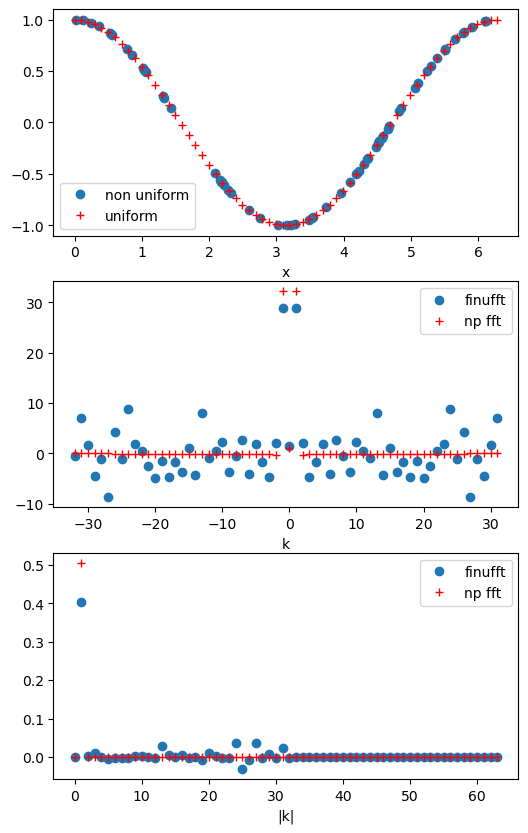

In [76]:
fig, ax = plt.subplots(3,1, figsize=(6,10))

ax[0].plot(xx, vec1d.real, ls='', marker='o', label='non uniform')
ax[0].plot(xx_uniform, vec1d_uniform.real, ls='', marker='+', color='r', label='uniform')
ax[0].set_xlabel('x')

ax[1].plot(k1d_target, vhat1d.real, ls='', marker='o', label='finufft')
ax[1].plot(k1d_target, vhat1d_numpy.real, ls='', marker='+', color='r', label='np fft')
ax[1].set_xlabel('k')

ax[2].plot(k_shell, powerspectr_finufft, ls='', marker='o', label='finufft')
ax[2].plot(k_shell, powerspectr_numpy, ls='', marker='+', color='r', label='np fft')
ax[2].set_xlabel('|k|')

ax[0].legend()
ax[1].legend()
ax[2].legend()

plt.show()

